# Benchmark SOTA trên Flickr8k TEST

Notebook này chạy các mô hình image captioning pretrained trên cùng tập TEST của đồ án, rồi tính BLEU-1/2/3/4, METEOR, ROUGE-L, CIDEr và đo số tham số/thời gian/VRAM.

**Lưu ý:** đây là so sánh suy luận với mô hình pretrained/fine-tuned công khai, không phải huấn luyện lại SOTA trên Flickr8k.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Đổi đúng đường dẫn project của bạn
%cd /content/drive/MyDrive/CS338

/content/drive/MyDrive/CS338


In [ ]:
!pip -q install transformers accelerate sentencepiece timm rouge-score pycocoevalcap nltk

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 9.5 MB/s eta 0:00:00


In [ ]:
import os, json, time, gc
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from nltk.translate.bleu_score import corpus_bleu
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer

try:
    from pycocoevalcap.cider.cider import Cider
    HAS_CIDER = True
except Exception as e:
    HAS_CIDER = False
    print("Không import được CIDEr:", e)

from datasets import CaptionDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
DATA_FOLDER = "/content/drive/MyDrive/CS338"
DATA_NAME = "flickr8k_5_cap_per_img_5_min_word_freq"
SPLIT = "TEST"

LIMIT = None

WORDMAP_PATH = os.path.join(DATA_FOLDER, f"WORDMAP_{DATA_NAME}.json")
with open(WORDMAP_PATH, "r") as f:
    word_map = json.load(f)

rev_word_map = {v:k for k,v in word_map.items()}
skip_ids = {word_map["<start>"], word_map["<end>"], word_map["<pad>"]}

print("Word map:", WORDMAP_PATH)
print("Vocab size:", len(word_map))

Word map: /content/drive/MyDrive/CS338/WORDMAP_flickr8k_5_cap_per_img_5_min_word_freq.json
Vocab size: 2633


Load TEST items: 100%|██████████| 1000/1000 [00:07<00:00, 128.13it/s]

Số ảnh benchmark: 1000
Ví dụ reference: ['two brown dogs playfully fight in the snow', 'two brown dogs wrestle in the snow']


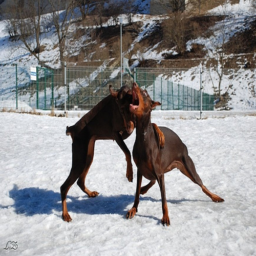

In [ ]:
def decode_ids(ids):
    words = []
    for w in ids:
        if int(w) in skip_ids:
            continue
        tok = rev_word_map.get(int(w), "<unk>")
        if tok not in {"<start>", "<end>", "<pad>"}:
            words.append(tok)
    return " ".join(words).strip()

def tensor_to_pil(img_tensor):
    # CaptionDataset trả img dạng [3, 256, 256], float trong [0,1] nếu transform=None
    arr = img_tensor.permute(1, 2, 0).numpy()
    arr = np.clip(arr * 255.0, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)

def load_test_items(limit=None):
    ds = CaptionDataset(DATA_FOLDER, DATA_NAME, SPLIT, transform=None)
    cpi = ds.cpi
    indices = list(range(0, len(ds), cpi))  # mỗi ảnh lấy 1 lần, nhưng allcaps vẫn đủ 5 captions
    if limit is not None:
        indices = indices[:limit]

    items = []
    for idx in tqdm(indices, desc="Load TEST items"):
        img, _cap, _caplen, allcaps = ds[idx]
        pil = tensor_to_pil(img)
        refs = [decode_ids(c.tolist()) for c in allcaps]
        items.append({
            "image_id": idx // cpi,
            "pil": pil,
            "references": refs,
        })
    return items

items = load_test_items(LIMIT)
print("Số ảnh benchmark:", len(items))
print("Ví dụ reference:", items[0]["references"][:2])
display(items[0]["pil"])

In [ ]:
def compute_caption_metrics(predictions, references_list):
    # predictions: list[str]
    # references_list: list[list[str]]
    refs_tok = [[r.lower().split() for r in refs] for refs in references_list]
    hyps_tok = [p.lower().split() for p in predictions]

    bleu1 = corpus_bleu(refs_tok, hyps_tok, weights=(1.0, 0, 0, 0))
    bleu2 = corpus_bleu(refs_tok, hyps_tok, weights=(0.5, 0.5, 0, 0))
    bleu3 = corpus_bleu(refs_tok, hyps_tok, weights=(1/3, 1/3, 1/3, 0))
    bleu4 = corpus_bleu(refs_tok, hyps_tok, weights=(0.25, 0.25, 0.25, 0.25))

    meteor_vals = [
        meteor_score([r.lower().split() for r in refs], pred.lower().split())
        for pred, refs in zip(predictions, references_list)
    ]
    meteor = float(np.mean(meteor_vals)) if meteor_vals else 0.0

    rouge_sc = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
    rouge_vals = []
    for pred, refs in zip(predictions, references_list):
        if len(refs) == 0:
            rouge_vals.append(0.0)
        else:
            rouge_vals.append(max(rouge_sc.score(r.lower(), pred.lower())["rougeL"].fmeasure for r in refs))
    rouge_l = float(np.mean(rouge_vals)) if rouge_vals else 0.0

    cider = None
    if HAS_CIDER:
        gts = {i: refs for i, refs in enumerate(references_list)}
        res = {i: [predictions[i]] for i in range(len(predictions))}
        cider, _ = Cider().compute_score(gts, res)
        cider = float(cider)

    return {
        "BLEU-1": bleu1,
        "BLEU-2": bleu2,
        "BLEU-3": bleu3,
        "BLEU-4": bleu4,
        "METEOR": meteor,
        "ROUGE-L": rouge_l,
        "CIDEr": cider,
    }

def count_model_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    param_mem_mb = sum(p.numel() * p.element_size() for p in model.parameters()) / (1024 ** 2)
    return total, trainable, param_mem_mb

def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

## Chạy BLIP-base

Model: `Salesforce/blip-image-captioning-base`.

In [ ]:
from transformers import BlipProcessor, BlipForConditionalGeneration

def run_blip_base(items, max_new_tokens=40, num_beams=5):
    clear_memory()
    model_id = "Salesforce/blip-image-captioning-base"
    processor = BlipProcessor.from_pretrained(model_id)
    model = BlipForConditionalGeneration.from_pretrained(model_id).to(device).eval()

    total_params, trainable_params, param_mem_mb = count_model_params(model)

    preds = []
    times = []

    for item in tqdm(items, desc="BLIP-base"):
        image = item["pil"]

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t0 = time.time()

        with torch.no_grad():
            inputs = processor(images=image, return_tensors="pt").to(device)
            out = model.generate(**inputs, max_new_tokens=max_new_tokens, num_beams=num_beams)
            caption = processor.decode(out[0], skip_special_tokens=True).strip()

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        times.append(time.time() - t0)
        preds.append(caption)

    peak_vram_mb = torch.cuda.max_memory_allocated() / (1024 ** 2) if torch.cuda.is_available() else None
    metrics = compute_caption_metrics(preds, [x["references"] for x in items])

    row = {
        "Model": "BLIP-base",
        "HF_ID": model_id,
        "Params": total_params,
        "Trainable_Params": trainable_params,
        "Param_Memory_MB": param_mem_mb,
        "Avg_Time_s_per_img": float(np.mean(times)),
        "Peak_VRAM_MB": peak_vram_mb,
        **metrics,
    }

    del model, processor
    clear_memory()
    return row, preds

blip_row, blip_preds = run_blip_base(items)
blip_row

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]


BLIP-base: 100%|██████████| 1000/1000 [05:20<00:00,  3.12it/s]


{'Model': 'BLIP-base',
 'HF_ID': 'Salesforce/blip-image-captioning-base',
 'Params': 247444600,
 'Trainable_Params': 247444600,
 'Param_Memory_MB': 943.9262390136719,
 'Avg_Time_s_per_img': 0.3166310875415802,
 'Peak_VRAM_MB': 1194.0546875,
 'BLEU-1': 0.7176458161928578,
 'BLEU-2': 0.5434377084379852,
 'BLEU-3': 0.39670763317579466,
 'BLEU-4': 0.2851854038066994,
 'METEOR': 0.48192651521777224,
 'ROUGE-L': 0.5321236544402862,
 'CIDEr': 0.8446138011838646}

## Chạy GIT-base-COCO

Model: `microsoft/git-base-coco`.

In [ ]:
from transformers import AutoProcessor, AutoModelForCausalLM

def run_git_base_coco(items, max_length=50, num_beams=5):
    clear_memory()
    model_id = "microsoft/git-base-coco"
    processor = AutoProcessor.from_pretrained(model_id)
    model = AutoModelForCausalLM.from_pretrained(model_id).to(device).eval()

    total_params, trainable_params, param_mem_mb = count_model_params(model)

    preds = []
    times = []

    for item in tqdm(items, desc="GIT-base-COCO"):
        image = item["pil"]

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t0 = time.time()

        with torch.no_grad():
            inputs = processor(images=image, return_tensors="pt").to(device)
            out = model.generate(
                pixel_values=inputs.pixel_values,
                max_length=max_length,
                num_beams=num_beams,
            )
            caption = processor.batch_decode(out, skip_special_tokens=True)[0].strip()

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        times.append(time.time() - t0)
        preds.append(caption)

    peak_vram_mb = torch.cuda.max_memory_allocated() / (1024 ** 2) if torch.cuda.is_available() else None
    metrics = compute_caption_metrics(preds, [x["references"] for x in items])

    row = {
        "Model": "GIT-base-COCO",
        "HF_ID": model_id,
        "Params": total_params,
        "Trainable_Params": trainable_params,
        "Param_Memory_MB": param_mem_mb,
        "Avg_Time_s_per_img": float(np.mean(times)),
        "Peak_VRAM_MB": peak_vram_mb,
        **metrics,
    }

    del model, processor
    clear_memory()
    return row, preds

git_row, git_preds = run_git_base_coco(items)
git_row

preprocessor_config.json:   0%|          | 0.00/503 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/2.82k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/453 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

GIT-base-COCO:   0%|          | 2/1000 [00:00<03:20,  4.97it/s]

model.safetensors:   0%|          | 0.00/707M [00:00<?, ?B/s]

GIT-base-COCO: 100%|██████████| 1000/1000 [03:14<00:00,  5.15it/s]


{'Model': 'GIT-base-COCO',
 'HF_ID': 'microsoft/git-base-coco',
 'Params': 176619066,
 'Trainable_Params': 176619066,
 'Param_Memory_MB': 673.7482681274414,
 'Avg_Time_s_per_img': 0.1929832601547241,
 'Peak_VRAM_MB': 784.2373046875,
 'BLEU-1': 0.614207777875813,
 'BLEU-2': 0.44470230188252396,
 'BLEU-3': 0.3060741066432308,
 'BLEU-4': 0.20927787614909446,
 'METEOR': 0.410583406603907,
 'ROUGE-L': 0.5056552442916478,
 'CIDEr': 0.5018643962367648}

## Tùy chọn: BLIP-2 OPT-2.7B


In [ ]:
RUN_BLIP2 = True

if RUN_BLIP2:
    from transformers import Blip2Processor, Blip2ForConditionalGeneration

    def run_blip2(items, max_new_tokens=40, num_beams=5):
        clear_memory()
        model_id = "Salesforce/blip2-opt-2.7b"
        processor = Blip2Processor.from_pretrained(model_id)

        dtype = torch.float16 if torch.cuda.is_available() else torch.float32
        model = Blip2ForConditionalGeneration.from_pretrained(
            model_id,
            torch_dtype=dtype,
            device_map="auto" if torch.cuda.is_available() else None,
        ).eval()

        total_params, trainable_params, param_mem_mb = count_model_params(model)

        preds = []
        times = []

        for item in tqdm(items, desc="BLIP-2 OPT-2.7B"):
            image = item["pil"]

            if torch.cuda.is_available():
                torch.cuda.synchronize()
            t0 = time.time()

            with torch.no_grad():
                inputs = processor(images=image, return_tensors="pt")
                if torch.cuda.is_available():
                    inputs = {k: v.to(device, dtype=dtype) if v.dtype.is_floating_point else v.to(device) for k, v in inputs.items()}
                out = model.generate(**inputs, max_new_tokens=max_new_tokens, num_beams=num_beams)
                caption = processor.decode(out[0], skip_special_tokens=True).strip()

            if torch.cuda.is_available():
                torch.cuda.synchronize()
            times.append(time.time() - t0)
            preds.append(caption)

        peak_vram_mb = torch.cuda.max_memory_allocated() / (1024 ** 2) if torch.cuda.is_available() else None
        metrics = compute_caption_metrics(preds, [x["references"] for x in items])

        row = {
            "Model": "BLIP-2 OPT-2.7B",
            "HF_ID": model_id,
            "Params": total_params,
            "Trainable_Params": trainable_params,
            "Param_Memory_MB": param_mem_mb,
            "Avg_Time_s_per_img": float(np.mean(times)),
            "Peak_VRAM_MB": peak_vram_mb,
            **metrics,
        }

        del model, processor
        clear_memory()
        return row, preds

    blip2_row, blip2_preds = run_blip2(items)
else:
    blip2_row, blip2_preds = None, None

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.03k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/882 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/122k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

BLIP-2 OPT-2.7B: 100%|██████████| 1000/1000 [07:46<00:00,  2.15it/s]


## Tổng hợp kết quả

In [ ]:
rows = [blip_row, git_row]
if blip2_row is not None:
    rows.append(blip2_row)

df = pd.DataFrame(rows)

# Thêm kết quả mô hình của nhóm nếu muốn so chung trong bảng.
# Số params/time của mô hình nhóm nên đo bằng script riêng hoặc demo_engine.
ours_metrics = {
    "Model": "Ours Final Beam5",
    "HF_ID": "checkpoint nhóm",
    "Params": None,
    "Trainable_Params": None,
    "Param_Memory_MB": None,
    "Avg_Time_s_per_img": None,
    "Peak_VRAM_MB": None,
    "BLEU-1": 0.7239,
    "BLEU-2": 0.5503,
    "BLEU-3": 0.4092,
    "BLEU-4": 0.2934,
    "METEOR": 0.4716,
    "ROUGE-L": 0.5241,
    "CIDEr": 0.7702,
}

df_full = pd.concat([pd.DataFrame([ours_metrics]), df], ignore_index=True)

display(df_full)

out_csv = f"sota_test_benchmark_{SPLIT.lower()}_{'full' if LIMIT is None else LIMIT}.csv"
df_full.to_csv(out_csv, index=False)
print("Đã lưu:", out_csv)

/tmp/ipykernel_2580/3482141029.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_full = pd.concat([pd.DataFrame([ours_metrics]), df], ignore_index=True)


,Model,HF_ID,Params,Trainable_Params,Param_Memory_MB,Avg_Time_s_per_img,Peak_VRAM_MB,BLEU-1,BLEU-2,BLEU-3,BLEU-4,METEOR,ROUGE-L,CIDEr
0,Ours Final Beam5,checkpoint nhóm,None,None,NaN,NaN,NaN,0.723900,0.550300,0.409200,0.293400,0.471600,0.524100,0.770200
1,BLIP-base,Salesforce/blip-image-captioning-base,247444600,247444600,943.926239,0.316631,1194.054688,0.717646,0.543438,0.396708,0.285185,0.481927,0.532124,0.844614
2,GIT-base-COCO,microsoft/git-base-coco,176619066,176619066,673.748268,0.192983,784.237305,0.614208,0.444702,0.306074,0.209278,0.410583,0.505655,0.501864
3,BLIP-2 OPT-2.7B,Salesforce/blip2-opt-2.7b,3744761856,3744761856,7343.147461,0.464742,7465.043457,0.752764,0.593048,0.450939,0.335534,0.529133,0.569856,0.997040


Đã lưu: sota_test_benchmark_test_full.csv


In [ ]:
# Lưu caption từng ảnh để đưa vào báo cáo/phân tích định tính
pred_rows = []
for i, item in enumerate(items):
    pred_rows.append({
        "image_id": item["image_id"],
        "references": " || ".join(item["references"]),
        "BLIP-base": blip_preds[i],
        "GIT-base-COCO": git_preds[i],
        "BLIP-2": blip2_preds[i] if blip2_preds is not None else None,
    })

pred_df = pd.DataFrame(pred_rows)
display(pred_df.head(10))

pred_csv = f"sota_test_predictions_{SPLIT.lower()}_{'full' if LIMIT is None else LIMIT}.csv"
pred_df.to_csv(pred_csv, index=False)
print("Đã lưu:", pred_csv)

,image_id,references,BLIP-base,GIT-base-COCO,BLIP-2
0,0,two brown dogs playfully fight in the snow || ...,a couple of dogs playing in the snow,two dogs playing in the snow.,two doberman pinschers playing in the snow
1,1,the small brown and white dog is in the pool |...,a man playing with a dog in a pool,a puppy in a swimming pool.,a man and a dog in a pool
2,2,one performer wearing a feathered headdress da...,a man and a woman dancing in the street,dancers perform during the parade.,a man and a woman dancing in the street
3,3,three people sit at an outdoor table in front ...,two people sitting at a table with umbrellas o...,two women sitting at a table outside a restaur...,a group of people sitting under an umbrella in...
4,4,a man is wearing a sooners red football shirt ...,a man in a red and white uniform holding a foo...,american football player during a football gam...,a football player in a red and white uniform
5,5,a brown dog running || a brown dog with its fr...,a dog running in the grass with a ball in its ...,a dog running in the grass.,a dog running in the grass with a frisbee in i...
6,6,two girls are looking past each other in diffe...,a group of people standing next to each other ...,girls in green hats,a woman wearing a green hat
7,7,close up of dog in profile with mouth open || ...,a brown and white dog with it ' s mouth open,a boxer dog yawning with its mouth open.,a brown and white dog with its mouth open
8,8,a black dog on a beach carrying a ball in its ...,a black dog with a white ball in its mouth,a black and white dog walking on a sandy beach.,a black dog with a frisbee in its mouth
9,9,two boys in green and white uniforms play bask...,a group of young men playing a game of basketball,a group of men playing basketball on a court.,a group of men playing a game of basketball


Đã lưu: sota_test_predictions_test_full.csv


In [5]:
!pip install -q -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.4 MB/s eta 0:00:00


In [8]:
import os
import sys
import torch

PROJECT_DIR = "/content/drive/MyDrive/CS338"
CHECKPOINT = "/content/drive/MyDrive/CS338/BEST_checkpoint_dual_stream_lstm_adaptive_FS5_RL_flickr8k_5_cap_per_img_5_min_word_freq.pth.tar"

os.chdir(PROJECT_DIR)
sys.path.insert(0, PROJECT_DIR)

print("Current dir:", os.getcwd())
print("Has models.py:", os.path.exists("models.py"))
print("Has checkpoint:", os.path.exists(CHECKPOINT))

import models

def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

ckpt = torch.load(CHECKPOINT, map_location="cpu", weights_only=False)

encoder = ckpt["encoder"]
decoder = ckpt["decoder"]

enc_total, enc_train = count_params(encoder)
dec_total, dec_train = count_params(decoder)

print("===== OUR MODEL PARAMS =====")
print(f"Encoder total:     {enc_total:,}")
print(f"Encoder trainable: {enc_train:,}")
print(f"Encoder frozen:    {enc_total - enc_train:,}")

print(f"Decoder total:     {dec_total:,}")
print(f"Decoder trainable: {dec_train:,}")
print(f"Decoder frozen:    {dec_total - dec_train:,}")

print(f"Full total:        {enc_total + dec_total:,}")
print(f"Full trainable:    {enc_train + dec_train:,}")
print(f"Full frozen:       {(enc_total + dec_total) - (enc_train + dec_train):,}")

param_memory_mb = (enc_total + dec_total) * 4 / (1024 ** 2)
print(f"Estimated parameter memory FP32: {param_memory_mb:.2f} MB")

Current dir: /content/drive/MyDrive/CS338
Has models.py: True
Has checkpoint: True
===== OUR MODEL PARAMS =====
Encoder total:     53,368,896
Encoder trainable: 43,857,920
Encoder frozen:    9,510,976
Decoder total:     13,980,746
Decoder trainable: 13,980,746
Decoder frozen:    0
Full total:        67,349,642
Full trainable:    57,838,666
Full frozen:       9,510,976
Estimated parameter memory FP32: 256.92 MB
